데이타가 깔끔하지도 않고 구조도 정해져 있지 않음
## 깔끔한 데이터 만들기 
> 데이터분석을 용이하게 하고 시각화를 수월하게 하기 위해서 데이터프레임이 깔끔한 구조를 가지는 것이 좋음.
  깔끔한 데이타는 무엇인가?

깔끔한 데이터란? -  
1. 변수들은 column(열)로 구성
2. 관측값은 row(행)로 구성
3. 값은 cell(셀)에 작성
위 규칙에 맞지 않게 만들어져있는 데이터셋이 있다면 구조를 변경하여 깔끔한 데이터프레임으로 만들서 분석함.

**사례별로 구조를 변경하면 깔끔한 데이터를 만들어보기** 
책 5챕터

In [1]:
#1. 열 이름이 관측값인 경우....(안좋은 구조)
# 비 깔끔한 데이터
import pandas as pd

data = [
    ["서울", 10, 12, 15],
    ["부산", 7, 9, 11]
]

df = pd.DataFrame(data, columns=["지역", "2021", "2022", "2023"])
df

,지역,2021,2022,2023
0,서울,10,12,15
1,부산,7,9,11


In [2]:
#문제1. 연도별 평균 판매액 구하기 
df[['2021','2022','2023']].mean()

#문제점
#연도 컴룸명을 직접 나열해야함.
#연도를 변수처럼 다루지 않아서..직관적이지 않음. 

2021     8.5
2022    10.5
2023    13.0
dtype: float64

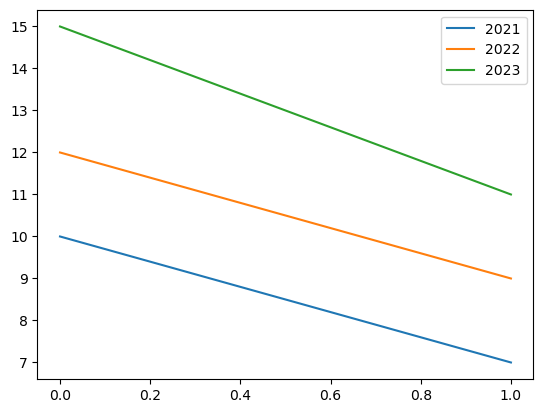

In [7]:
#문제2. 시각화 할때 짜증 -- 뭔지 잘 안 읽혀짐.
#통상적으로 그래프를 그릴때 
#관측값이 x축
# 각 변수의 값들이 y축 

#연도별 추이를 그리고 싶어....
import matplotlib.pyplot as plt
plt.plot(df['2021'],label='2021' )
plt.plot(df['2022'],label='2022' )
plt.plot(df['2023'],label='2023' )
plt.legend()
plt.show()



In [17]:
#깔끔한 데이터로 변경.. 방법[ .melt()]

df_tidy = df.melt(
    id_vars='지역',     # 그대로 유지될 컬룸 지정
    value_vars=['2021','2022','2023'], # '녹여서'행으로 변환될 컴룰명들.(지정하지 않으면 모두) 안쓰면 다..
    var_name='연도', #기존 컬룸명이 값이된 컬룸명의 이름지정
    value_name = '매출액' #값들이 들어간 컴룸의 이름지정

)



df_tidy

,지역,연도,매출액
0,서울,2021,10
1,부산,2021,7
2,서울,2022,12
3,부산,2022,9
4,서울,2023,15
5,부산,2023,11


In [18]:
#6교시
df = df_tidy.sort_values(by=['지역'],ascending=False)
df

,지역,연도,매출액
0,서울,2021,10
2,서울,2022,12
4,서울,2023,15
1,부산,2021,7
3,부산,2022,9
5,부산,2023,11


In [19]:
df=df.reset_index(drop=True)
df

,지역,연도,매출액
0,서울,2021,10
1,서울,2022,12
2,서울,2023,15
3,부산,2021,7
4,부산,2022,9
5,부산,2023,11


In [20]:
#연도별 매출액 평균
df.groupby('연도')['매출액'].mean()


연도
2021     8.5
2022    10.5
2023    13.0
Name: 매출액, dtype: float64

In [21]:
#특정연도 필터링
df[df['연도']=='2022']

,지역,연도,매출액
1,서울,2022,12
4,부산,2022,9


<Axes: xlabel='연도', ylabel='매출액'>

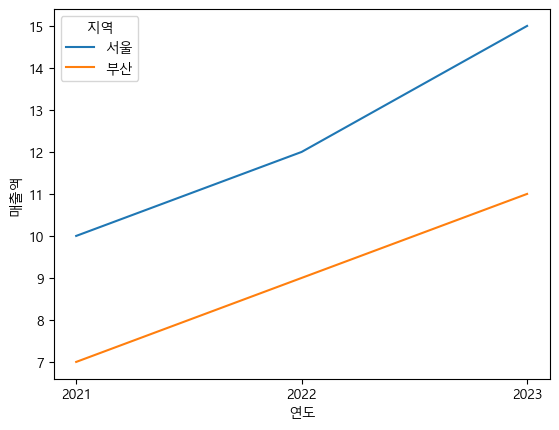

In [22]:
#시각화
import matplotlib.pyplot as plt
import seaborn as sns 

plt.rcParams['font.family']='Malgun Gothic' # 윈도우즈에 항상 있음 mac에서는 apple Gothic # rc : run time configure
sns.lineplot(data = df , x='연도', y='매출액',hue='지역')  # 기본적으로 한글 안됨. 

In [23]:
#분석 및 집계가 끝나면 melt했던 데이터프레임의 행렬을 원위치 할 수도 있음. ( 행<->열) 행은 열로 열은 행으로
df_again= df.pivot(  # 축을 기준으로 돌리다... 농구할때 한축을 기준으로 돌리는 것을 비유
    index = '지역',
    columns = '연도',
    values = '매출액',
) 

df_again

연도,2021,2022,2023
지역,,,
부산,7,9,11
서울,10,12,15


In [24]:
#사례2. 하나의 셀에 여러개의 값이 있는 경우.

# 원래 데이터
df= pd.DataFrame([
    ['철수', '남_20'],
    ['영희', '여_22'],
], columns=['이름','성별_나이'])
df

,이름,성별_나이
0,철수,남_20
1,영희,여_22


In [27]:
#성별 나이를 분리하여 각각의 컬룸에 넣기
df[['성별','나이']] = df['성별_나이'].str.split('_',expand=True) # 결과를 파이썬 리스트로 돌려줌.
# expand=True : 나눈 결과를 리스트 형태가 아닌, 여러개의 새로운 컬룸을 가진 데이터프레임으로 반환

# df[['성별','나이']] = df['성별_나이'].str.split('_',expand=False)
df

,이름,성별_나이,성별,나이
0,철수,남_20,남,20
1,영희,여_22,여,22


In [29]:
#사례3. 구조는 좋은데.. 중복 데이터가 너무 많아서.. 집계agregation 해서 관리
#예제 데이터 (깔끔한 데이터지만 중복 존재)
import pandas as pd

df = pd.DataFrame({
    "지역": ["서울","서울","서울","부산","부산","부산"],
    "연도": [2021, 2021, 2022, 2021, 2022, 2022],
    "월":   [1, 2, 1, 1, 1, 2],
    "판매액": [5, 7, 12, 7, 9, 11]
})

df

,지역,연도,월,판매액
0,서울,2021,1,5
1,서울,2021,2,7
2,서울,2022,1,12
3,부산,2021,1,7
4,부산,2022,1,9
5,부산,2022,2,11


In [33]:
#지역별, 연도별로 묶어서 총매출액의 총합 , 평균을 집계한 데이터프레임으로 변경
df2 = df.pivot_table( # pivot 은 돌리기만 하는것이고 pivot_table은 집계까지 하는 것
    index = '지역',
    columns = '연도',
    values = '판매액',
    aggfunc=['sum','mean']

)
df2

# melt 는 wide 를 long 세로로 , aggregation은 long을 wide로 

sum      mean      
연도 2021 2022 2021  2022
지역                     
부산    7   20  7.0  10.0
서울   12   12  6.0  12.0

## 수행과제 : chapter 03, 05, 11읽고 예제 모두 따라하기! 